<a href="https://colab.research.google.com/github/sasi-nk/BSC_DPDM2025/blob/main/Project_BSC_Group2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

กลุ่มที่ 2
1. นางสาวกรวลัย แสนสิงห์            663020276-9
2. นางสาวศศิกานต์ ทิพย์สูงเนิน     663020297-1
3. นางสาวบุณยนุช อินทวงษ์          663020582-2
4. นายวชิรวิทย์ มูลละออง              663020584-8

**เล่ม Colab**

[Colab TransformedTargetRegressor นางสาวกรวลัย แสนสิงห์](https://colab.research.google.com/drive/1hRtgWbJTP_9erBb45ZKnQIRV8wlderxY)

[Colab DecisionTreeRegressor นางสาวบุณยนุช อินทวงษ์](https://colab.research.google.com/drive/1dh24AUSjeClFD-S7CZEUdy6tD8Xm_QJH?usp=sharing)

[Colab LSTM นายวชิรวิทย์ มูลละออง](https://drive.google.com/file/d/1PshafWrGYw5WIS9ynfGrHnDEapBREufP/view?usp=sharing)

# CCA Model

In [26]:
%pip install torch_geometric

In [27]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


In [28]:
"""
CCA (Canonical Correlation Analysis) Model for Rainfall Prediction
===================================================================
Pipeline adapted from LSTM_V23_11_TMD_ALLcluster_clean.py
- Same data loading, preprocessing, feature selection, and train/test split
- Replaces LSTM with CCA for dimensionality reduction + correlation analysis
- Uses CCA components as features for a Ridge regression predictor
"""

import os
import copy
import random
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from dateutil.relativedelta import relativedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  HYPERPARAMETERS

In [30]:
cluster        = 6          # same cluster used in LSTM script
window_size    = 12         # window size (reduced from 24 for CCA to gain test samples)
horizon        = 12         # same prediction horizon
k_fold_num     = 2          # same number of folds
n_components   = 4          # CCA latent dimensions to keep
ridge_alpha    = 1.0        # Ridge regularisation

DATA_DIR   = '/content/drive/MyDrive/KKU_Workshop3'
OUTPUT_DIR = '/content/drive/MyDrive/KKU_Workshop3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(10)
np.random.seed(10)

## 1. LOAD DATA

In [31]:
print("=" * 60)
print("1. Loading data ...")

X_index     = pd.read_csv(os.path.join(DATA_DIR, 'X_variable(Index)_operation_v4.csv'))
Y_rainfall  = pd.read_csv(os.path.join(DATA_DIR, 'Y_variable(Rainfall).csv'))
node        = pd.read_csv(os.path.join(DATA_DIR, 'Node_table_TMD.csv'))
feature_tbl = pd.read_csv(os.path.join(DATA_DIR, 'lookup_table_reanalysis_v5.csv'))

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')

print(f"  X_index shape   : {X_index.shape}")
print(f"  Y_rainfall shape: {Y_rainfall.shape}")

1. Loading data ...
  X_index shape   : (541, 11)
  Y_rainfall shape: (771, 133)


##  2. APPLY TIME LAGS

In [32]:
print("\n2. Applying time lags ...")

time_lags = {
    'MEIV2'       : [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE'       : [1],
    'PDO'         : [1, 2],
    'ONI'         : [1, 2],
    'DMI'         : [1, 2],
    'BSISO1'      : [1],
    'BSISO1-Phase': [1],
    'SWM'         : [1],
}

def apply_time_lag(df, col, lag):
    df[f"{col}_lag{lag}"] = df[col].shift(lag)
    return df

for col, lags in time_lags.items():
    if col in X_index.columns:
        for lg in lags:
            X_index = apply_time_lag(X_index, col, lg)


2. Applying time lags ...


## 3. DATA CLEANING  (fill NaN with monthly median)

In [33]:
print("3. Cleaning rainfall data ...")

Y_rainfall_clean = Y_rainfall.copy()
HQ_month         = Y_rainfall.copy()
HQ_month['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for m in range(1, 13):
    av = HQ_month[HQ_month['DATE'] == m].iloc[:, 1:].median()
    d  = {'MONTH': m}
    d.update(av)
    month_avg_list.append(d)
HQ_month_avg = pd.DataFrame(month_avg_list)

dates_month = pd.to_datetime(Y_rainfall_clean['DATE']).dt.month
for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(len(Y_rainfall_clean)):
        if np.isnan(Y_rainfall_clean.iloc[j, i]):
            Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[dates_month.iloc[j] - 1, i]

3. Cleaning rainfall data ...


##  4. DATE ALIGNMENT

In [34]:
print("4. Aligning date ranges ...")

start_training_date = '1982-01-01'

X_index['DATE']          = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])

max_date_possible = min(X_index['DATE'].max(), Y_rainfall_clean['DATE'].max())

con_X = (X_index['DATE'] >= start_training_date)          & (X_index['DATE'] <= max_date_possible)
con_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

X_index_interval  = X_index.loc[con_X, :]
Y_rainfall_clean  = Y_rainfall_clean.loc[con_Y, :]
Y_rainfall_interval = copy.deepcopy(Y_rainfall_clean)

start_training_date = Y_rainfall_clean['DATE'].min()
max_date_possible   = min(X_index_interval['DATE'].max(), Y_rainfall_clean['DATE'].max())

con_X = (X_index['DATE'] >= start_training_date)          & (X_index['DATE'] <= max_date_possible)
con_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

X_index_interval  = X_index.loc[con_X, :]
Y_rainfall_clean  = Y_rainfall_clean.loc[con_Y, :]

print(f"  Date range: {start_training_date.date()} → {max_date_possible.date()}")
print(f"  X rows: {len(X_index_interval)} | Y rows: {len(Y_rainfall_clean)}")

4. Aligning date ranges ...
  Date range: 1982-01-01 → 2025-03-01
  X rows: 519 | Y rows: 519


## 5. SET DATE AS INDEX

In [35]:
X_idx = X_index_interval.set_index('DATE')
Y_idx = Y_rainfall_clean.set_index('DATE')

## 6. STANDARDIZE

In [36]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_norm_arr = scaler_X.fit_transform(X_idx)
Y_norm_arr = scaler_Y.fit_transform(Y_idx)

X_norm_df = pd.DataFrame(X_norm_arr, index=X_idx.index, columns=X_idx.columns)
Y_norm_df = pd.DataFrame(Y_norm_arr, index=Y_idx.index, columns=Y_idx.columns)

print('X normalized shape:', X_norm_df.shape)
print('Y normalized shape:', Y_norm_df.shape)

X normalized shape: (519, 24)
Y normalized shape: (519, 132)


##  7. ADD CYCLIC MONTH FEATURES

In [37]:
X_norm_df['Month_sin'] = np.sin(2 * np.pi * X_norm_df.index.month / 12)
X_norm_df['Month_cos'] = np.cos(2 * np.pi * X_norm_df.index.month / 12)

n_feature_climate = X_norm_df.shape[1]
feature_climate   = X_norm_df.columns

X_norm_df.dropna(inplace=True)

print('After lag/dropna — X shape:', X_norm_df.shape)
print('After lag/dropna — Y shape:', Y_norm_df.shape)

After lag/dropna — X shape: (519, 26)
After lag/dropna — Y shape: (519, 132)


##  8. FEATURE SELECTION (lookup table)

In [38]:
print("6. Selecting features for cluster", cluster, "...")

feature_cluster  = feature_tbl[feature_tbl['Cluster'] == cluster]
selected_index   = []

for fi in range(len(feature_cluster)):
    row = feature_cluster.iloc[fi]
    if row['lag'] == 0:
        for i, fc in enumerate(feature_climate):
            if fc == row['Node']:
                selected_index.append(i)
    else:
        lag_name = f"{row['Node']}_lag{int(row['lag'])}"
        for i, fc in enumerate(feature_climate):
            if fc == lag_name:
                selected_index.append(i)
                break

selected_index = sorted(set(selected_index))
climate_name_list = [feature_climate[i] for i in selected_index]
print(f"  Selected climate features: {climate_name_list}")

6. Selecting features for cluster 6 ...
  Selected climate features: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


##  9. IDENTIFY CLUSTER STATIONS

In [39]:
cluster_station = [
    i for i in range(len(Y_norm_df.columns))
    if node['quality'].iloc[i] == 1 and node['cluster'].iloc[i] == cluster
]
station_names = [str(Y_norm_df.columns[i]) for i in cluster_station]
print(f"  Cluster {cluster} stations ({len(cluster_station)}): {station_names}")

  Cluster 6 stations (7): ['351201', '376201', '376202', '376401', '378201', '379201', '379401']


### นำเข้าโมเดล CCA

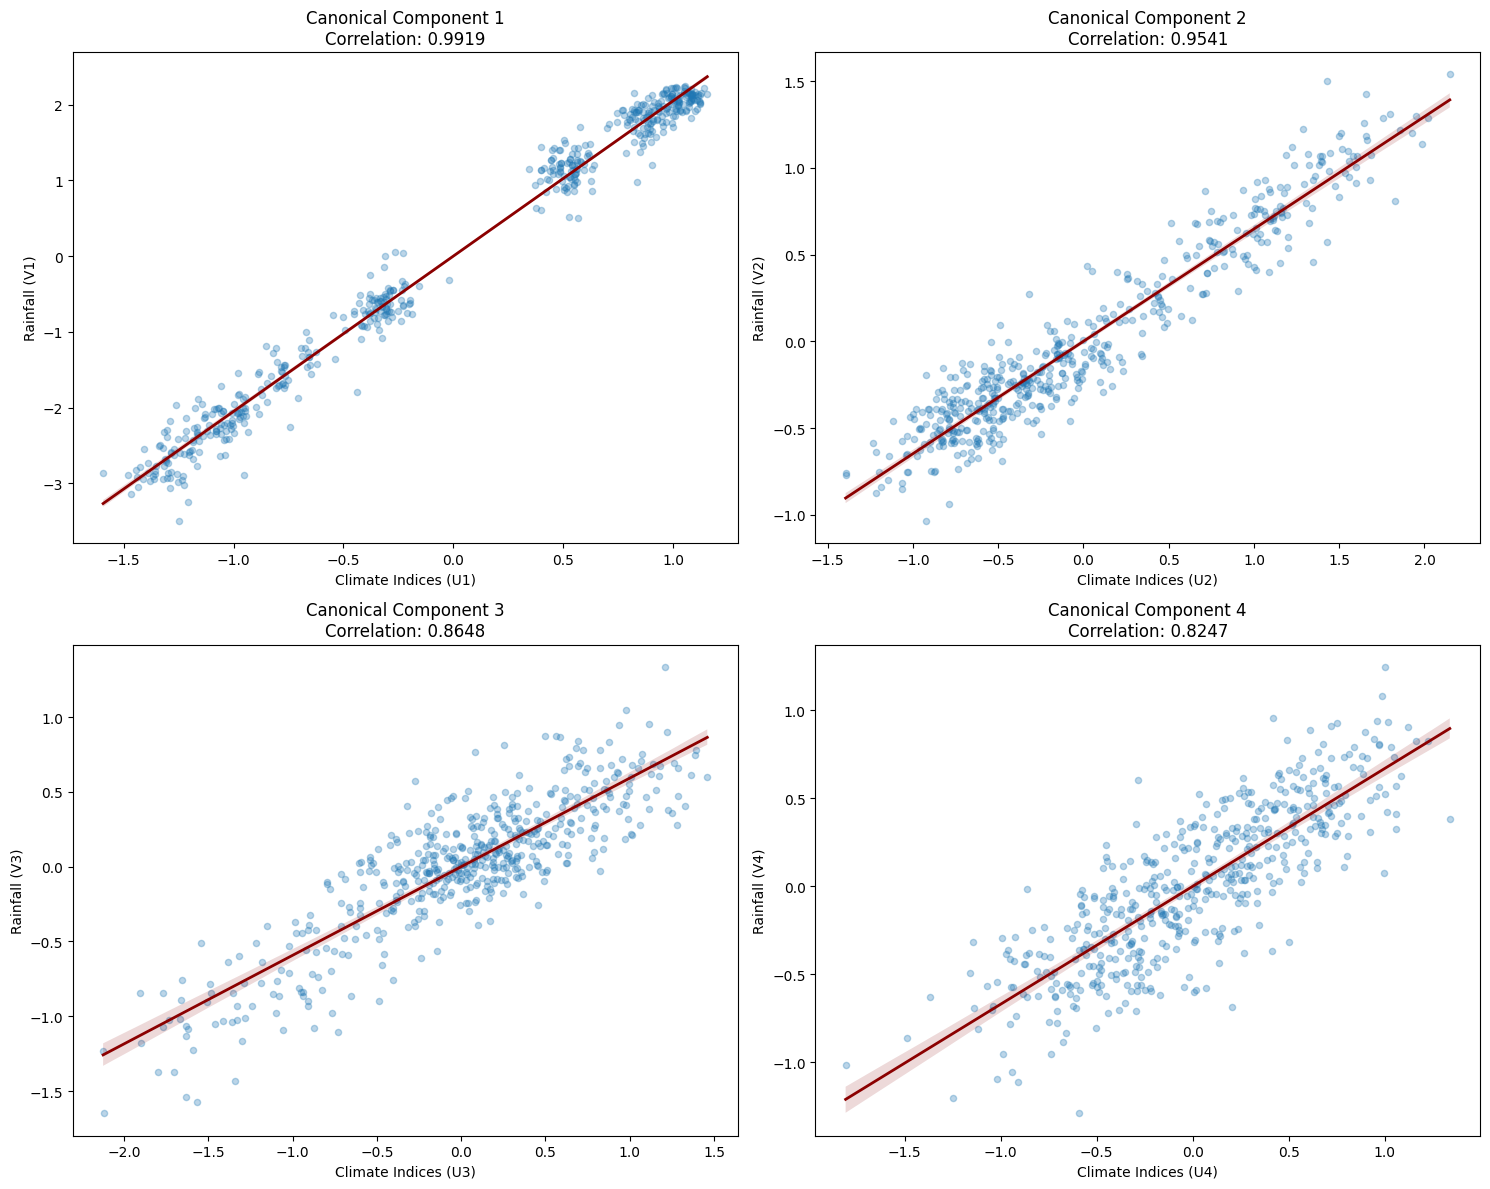

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
import pandas as pd
import numpy as np

# 1. กำหนดจำนวน Components
n_comp = 4
cca = CCA(n_components=n_comp)
cca.fit(X_norm_df, Y_norm_df )

# 2. แปลงข้อมูลเป็น Canonical Variates
U, V = cca.transform(X_norm_df, Y_norm_df)

# 3. Scatter Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i in range(n_comp):
    corr_val = np.corrcoef(U[:, i], V[:, i])[0, 1]
    sns.regplot(x=U[:, i], y=V[:, i], ax=axes[i],
                scatter_kws={'alpha':0.3, 's':20},
                line_kws={'color':'darkred', 'lw':2})
    axes[i].set_title(f'Canonical Component {i+1}\nCorrelation: {corr_val:.4f}', fontsize=12)
    axes[i].set_xlabel(f'Climate Indices (U{i+1})')
    axes[i].set_ylabel(f'Rainfall (V{i+1})')

plt.tight_layout()
plt.show()

In [41]:
# Create DataFrames for X and Y loadings
x_loadings_df = pd.DataFrame(cca.x_loadings_, index=X_norm_df.columns, columns=[f'Component {i+1}' for i in range(n_comp)])
y_loadings_df = pd.DataFrame(cca.y_loadings_, index=Y_norm_df.columns, columns=[f'Component {i+1}' for i in range(n_comp)])

print("### Summary of X Loadings (Climate Indices) for each Canonical Component")
print("แสดง 5 อันดับแรกของดัชนีภูมิอากาศที่มีอิทธิพลต่อแต่ละ Component (จากค่าสัมบูรณ์ของ Loading)")
for comp in x_loadings_df.columns:
    print(f"\n--- {comp} ---")
    top_x_loadings = x_loadings_df[comp].abs().sort_values(ascending=False).head(5)
    # Display actual loadings for the top features
    display(x_loadings_df.loc[top_x_loadings.index, [comp]].sort_values(by=comp, ascending=False))

print("\n### Summary of Y Loadings (Rainfall Stations) for each Canonical Component")
print("แสดง 5 อันดับแรกของสถานีวัดน้ำฝนที่ตอบสนองต่อแต่ละ Component (จากค่าสัมบูรณ์ของ Loading)")
for comp in y_loadings_df.columns:
    print(f"\n--- {comp} ---")
    top_y_loadings = y_loadings_df[comp].abs().sort_values(ascending=False).head(5)
    # Display actual loadings for the top stations
    display(y_loadings_df.loc[top_y_loadings.index, [comp]].sort_values(by=comp, ascending=False))

### Summary of X Loadings (Climate Indices) for each Canonical Component
แสดง 5 อันดับแรกของดัชนีภูมิอากาศที่มีอิทธิพลต่อแต่ละ Component (จากค่าสัมบูรณ์ของ Loading)

--- Component 1 ---


,Component 1
NE,1.055667
RMM_AMPLITUDE,0.995308
SWM,0.950286
BSISO1-Phase,-0.886552
BSISO1,-1.034646



--- Component 2 ---


,Component 2
Month_cos,0.813008
BSISO1_lag1,0.624386
BSISO1-Phase_lag1,0.558187
SWM_lag1,-0.664841
Month_sin,-0.805797



--- Component 3 ---


...

,Component 2
552202,1.270062
551202,1.052197
568501,1.004280
568401,0.973816
568301,0.925910



--- Component 3 ---


,Component 3
459204,-0.783245
431301,-0.826686
376201,-0.873888
328202,-0.892136
376203,-0.963652



--- Component 4 ---


,Component 4
560301,-0.893547
580201,-0.899832
568501,-0.931156
568301,-0.940170
552202,-1.049738


##  10. TRAIN / VAL / TEST SPLITS

In [42]:
t0 = pd.to_datetime(Y_norm_df.index.min())

# Fold 1
tr1_end   = t0 + relativedelta(months=37*12+11)
val1_start = t0 + relativedelta(months=36*12);  val1_end = t0 + relativedelta(months=38*12+11)
te1_start  = t0 + relativedelta(months=37*12);   te1_end  = t0 + relativedelta(months=39*12+11)

# Fold 2
tr2_start   = t0
tr2_end   = t0 + relativedelta(months=40*12)
val2_start = t0 + relativedelta(months=39*12);  val2_end = t0 + relativedelta(months=41*12+11)
te2_start  = t0 + relativedelta(months=40*12);   te2_end  = t0 + relativedelta(months=42*12+11)

def slice_df(df, s, e):
    mask = (df.index >= s) & (df.index <= e)
    return df[mask]

splits = {
    0: {
        'train': (t0,        tr1_end),
        'val'  : (val1_start, val1_end),
        'test' : (te1_start,  te1_end),
    },
    1: {
        'train': (t0,        tr2_end),
        'val'  : (val2_start, val2_end),
        'test' : (te2_start,  te2_end),
    },
}

for fi, sp in splits.items():
    for k, (s, e) in sp.items():
        rows = ((X_norm_df.index >= s) & (X_norm_df.index <= e)).sum()
        print(f"  Fold {fi+1} {k:5s}: {s.date()} → {e.date()}  ({rows} months)")

  Fold 1 train: 1982-01-01 → 2019-12-01  (456 months)
  Fold 1 val  : 2018-01-01 → 2020-12-01  (36 months)
  Fold 1 test : 2019-01-01 → 2021-12-01  (36 months)
  Fold 2 train: 1982-01-01 → 2022-01-01  (481 months)
  Fold 2 val  : 2021-01-01 → 2023-12-01  (36 months)
  Fold 2 test : 2022-01-01 → 2024-12-01  (36 months)


##  11. SLIDING WINDOW → FLAT MATRICES

In [43]:
def build_windows(X_df, Y_df, start, end):
    """
    Build (X_window, Y_window) pairs using a sliding window.
    X_window : [n_samples, n_climate_features * window_size]
    Y_window : [n_samples, n_stations * horizon]
    """
    X_sub = slice_df(X_df[climate_name_list], start, end).values   # [T, n_feat]
    Y_sub = np.column_stack(
        [slice_df(Y_df[[Y_df.columns[s]]], start, end).values.ravel()
         for s in cluster_station]
    )   # [T, n_stations]

    T = min(len(X_sub), len(Y_sub))
    X_sub = X_sub[:T]
    Y_sub = Y_sub[:T]

    Xw, Yw = [], []
    for j in range(T - window_size - horizon + 1):
        x_win = X_sub[j: j + window_size].ravel()           # flatten time × features
        y_win = Y_sub[j + window_size: j + window_size + horizon].ravel()
        Xw.append(x_win)
        Yw.append(y_win)

    return np.array(Xw), np.array(Yw)

##  12. METRICS

In [44]:
def nse_score(obs, pred):
    """Nash-Sutcliffe Efficiency"""
    denom = np.sum((obs - obs.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((obs - pred) ** 2) / denom

def rmse(obs, pred):
    return np.sqrt(mean_squared_error(obs, pred))

##  13. TRAIN CCA + RIDGE  PER FOLD


8. Training CCA + Ridge models ...

  Fold 1
    Train : X(433, 96)  Y(433, 84)
    Val   : X(13, 96)  Y(13, 84)
    Test  : X(13, 96)  Y(13, 84)
    Canonical correlations (train): ['0.989', '0.985', '0.931', '0.923']
    Val  R²        : 0.5186
    Test R²        : 0.5488
    Test NSE       : 0.5488
    Test RMSE      : 0.5470

  Fold 2
    Train : X(458, 96)  Y(458, 84)
    Val   : X(13, 96)  Y(13, 84)
    Test  : X(13, 96)  Y(13, 84)
    Canonical correlations (train): ['0.988', '0.984', '0.932', '0.924']
    Val  R²        : 0.5736
    Test R²        : 0.5568
    Test NSE       : 0.5568
    Test RMSE      : 0.7029


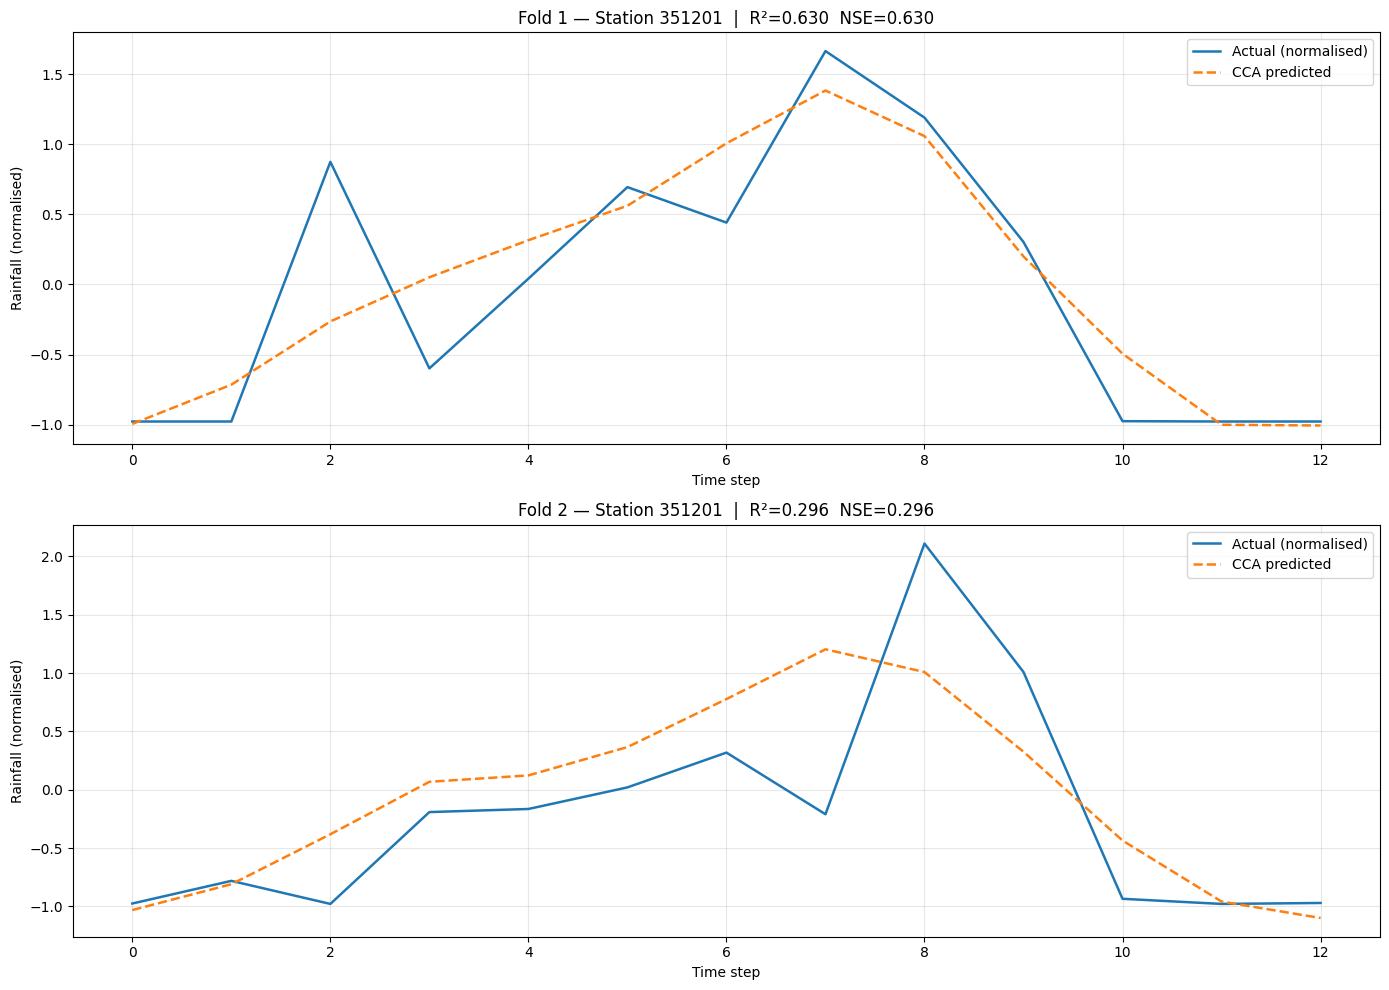

In [45]:
print("\n8. Training CCA + Ridge models ...")
print("=" * 60)

fold_results = []
fig_folds, axes_folds = plt.subplots(k_fold_num, 1, figsize=(14, 5 * k_fold_num))

for fold_idx in range(k_fold_num):
    sp = splits[fold_idx]

    X_tr, Y_tr  = build_windows(X_norm_df, Y_norm_df, sp['train'][0], sp['train'][1])
    X_val, Y_val = build_windows(X_norm_df, Y_norm_df, sp['val'][0],   sp['val'][1])
    X_te, Y_te  = build_windows(X_norm_df, Y_norm_df, sp['test'][0],  sp['test'][1])

    print(f"\n  Fold {fold_idx+1}")
    print(f"    Train : X{X_tr.shape}  Y{Y_tr.shape}")
    print(f"    Val   : X{X_val.shape}  Y{Y_val.shape}")
    print(f"    Test  : X{X_te.shape}  Y{Y_te.shape}")

    # ── CCA ──────────────────────────────
    n_comp = min(n_components, X_tr.shape[1], Y_tr.shape[1], X_tr.shape[0] - 1)
    cca = CCA(n_components=n_comp, max_iter=1000)
    cca.fit(X_tr, Y_tr)

    # Transform to canonical space
    Xc_tr,  Yc_tr  = cca.transform(X_tr,  Y_tr)
    Xc_val, Yc_val = cca.transform(X_val, Y_val)
    Xc_te,  Yc_te  = cca.transform(X_te,  Y_te)

    # Canonical correlations on training set
    canon_corrs = [np.corrcoef(Xc_tr[:, k], Yc_tr[:, k])[0, 1] for k in range(n_comp)]
    print(f"    Canonical correlations (train): {[f'{c:.3f}' for c in canon_corrs]}")

    # ── Ridge Regression on CCA scores ──
    ridge = Ridge(alpha=ridge_alpha)
    ridge.fit(Xc_tr, Y_tr)

    Y_pred_val = ridge.predict(Xc_val)
    Y_pred_te  = ridge.predict(Xc_te)

    # ── Metrics (averaged over stations) ──
    r2_val_list, r2_te_list, nse_te_list, rmse_te_list = [], [], [], []
    for i in range(len(cluster_station)):
        yt_v  = Y_val[:, i]
        yp_v  = Y_pred_val[:, i]
        yt_te = Y_te[:,  i]
        yp_te = Y_pred_te[:, i]


        r2_val_list.append(r2_score(yt_v, yp_v))
        r2_te_list.append(r2_score(yt_te, yp_te))
        nse_te_list.append(nse_score(yt_te, yp_te))
        rmse_te_list.append(rmse(yt_te, yp_te))

    avg = {
        'fold'     : fold_idx + 1,
        'r2_val'   : np.nanmean(r2_val_list),
        'r2_test'  : np.nanmean(r2_te_list),
        'nse_test' : np.nanmean(nse_te_list),
        'rmse_test': np.nanmean(rmse_te_list),
        'canon_corr_mean': np.mean(canon_corrs),
    }
    fold_results.append(avg)

    print(f"    Val  R²        : {avg['r2_val']:.4f}")
    print(f"    Test R²        : {avg['r2_test']:.4f}")
    print(f"    Test NSE       : {avg['nse_test']:.4f}")
    print(f"    Test RMSE      : {avg['rmse_test']:.4f}")

    # ── Plot: actual vs predicted for first station ──
    ax = axes_folds[fold_idx] if k_fold_num > 1 else axes_folds
    ax.plot(Y_te[:, i], label='Actual (normalised)', linewidth=1.8)
    ax.plot(Y_pred_te[:, i], label='CCA predicted',  linewidth=1.8, linestyle='--')
    ax.set_title(f"Fold {fold_idx+1} — Station {station_names[0]}  |  "
                 f"R²={r2_te_list[0]:.3f}  NSE={nse_te_list[0]:.3f}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Rainfall (normalised)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'cca_actual_vs_predicted.png'), dpi=130)
plt.show()


8. Training CCA + Ridge models ...

--- Fold 1 ---
Generating plots for Fold 1...


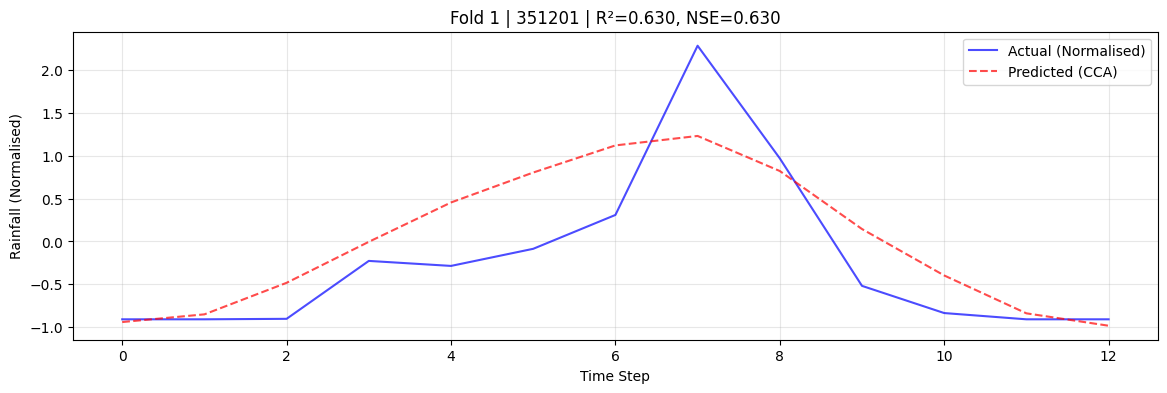

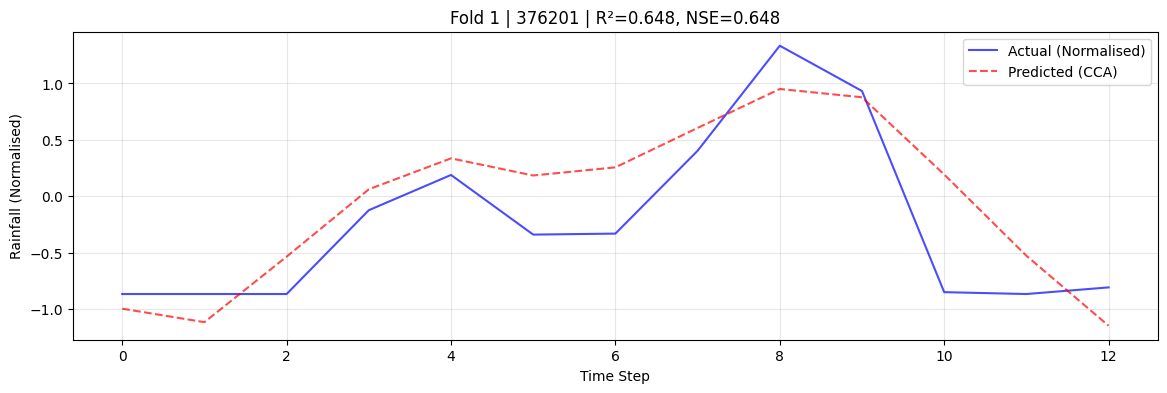

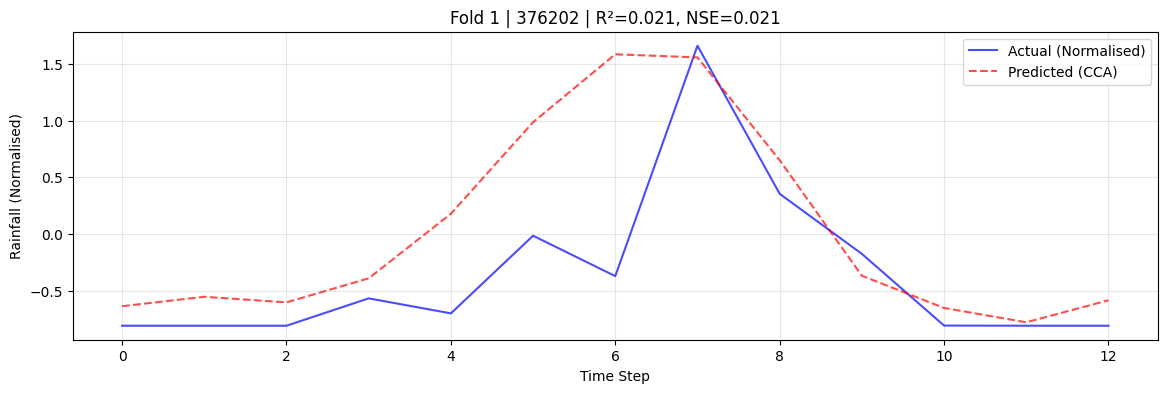

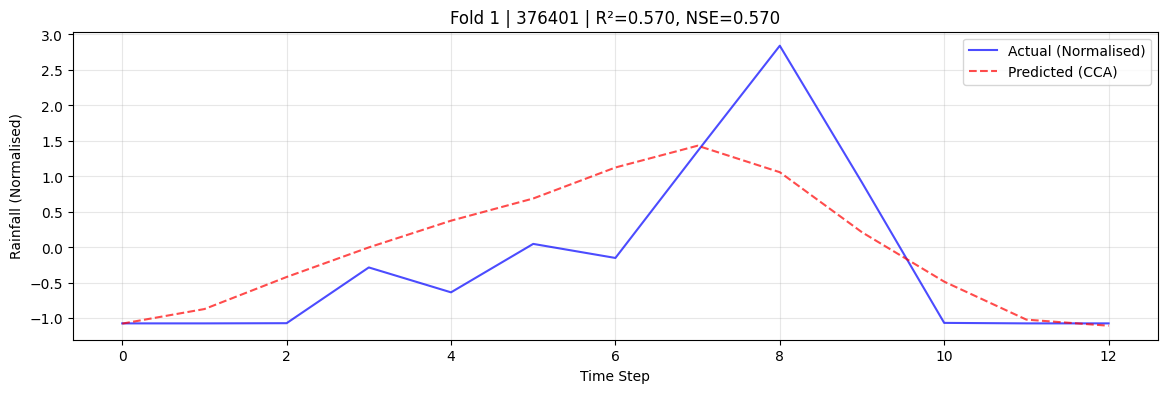

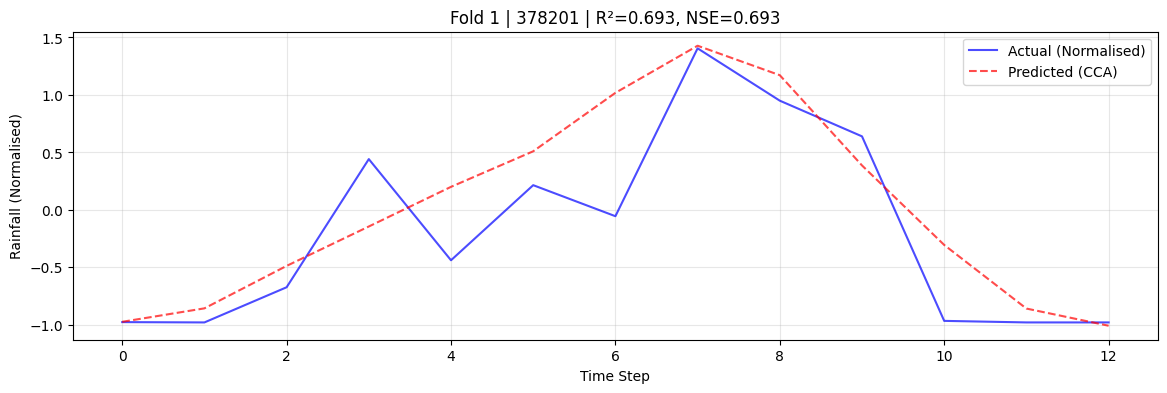

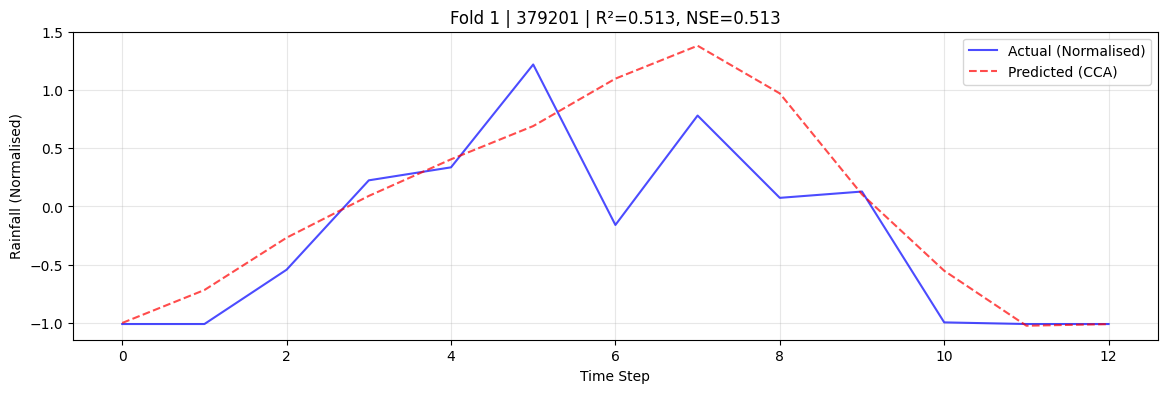

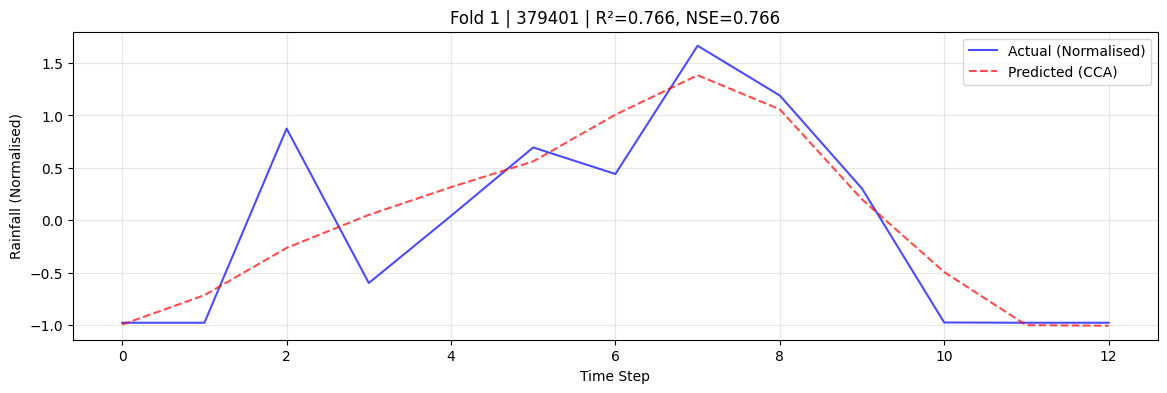

--- Finished Fold 1 ---

--- Fold 2 ---
Generating plots for Fold 2...


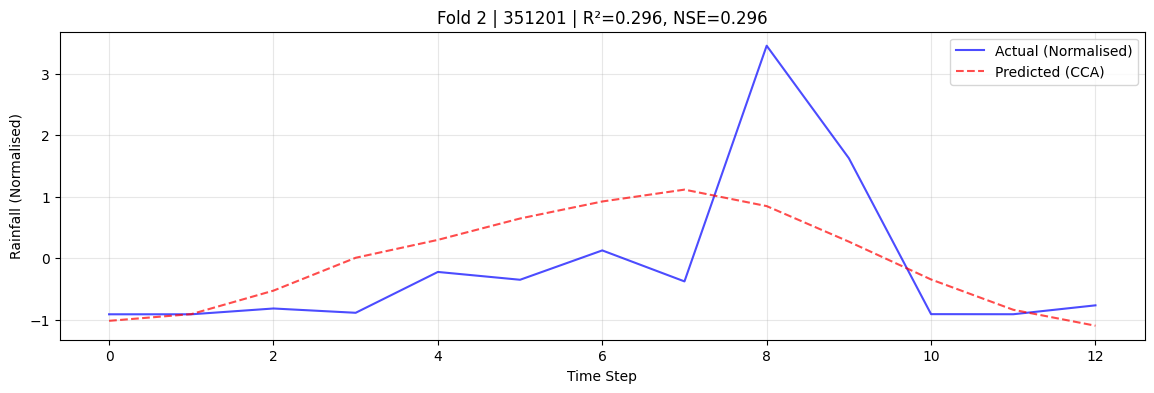

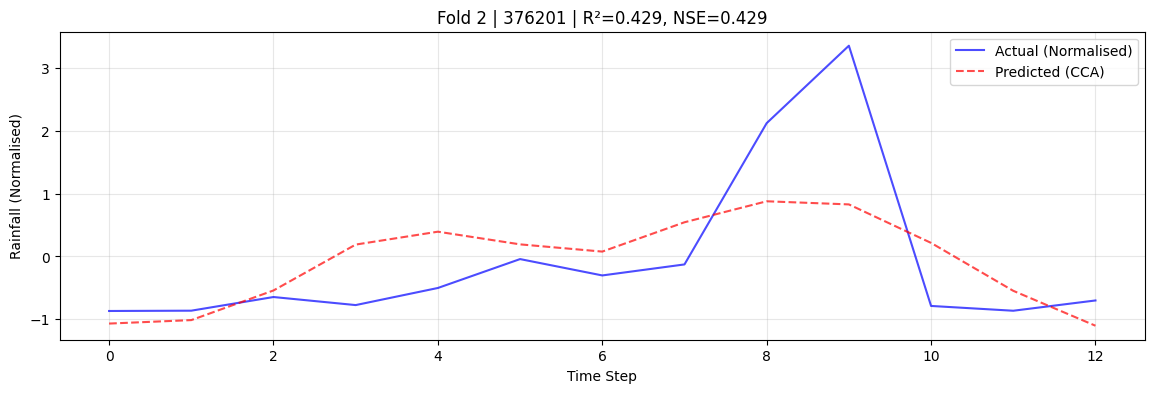

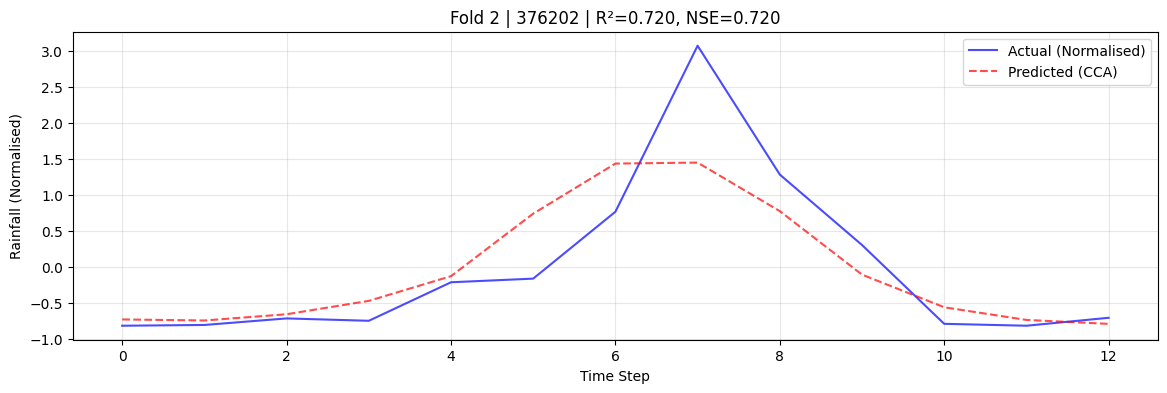

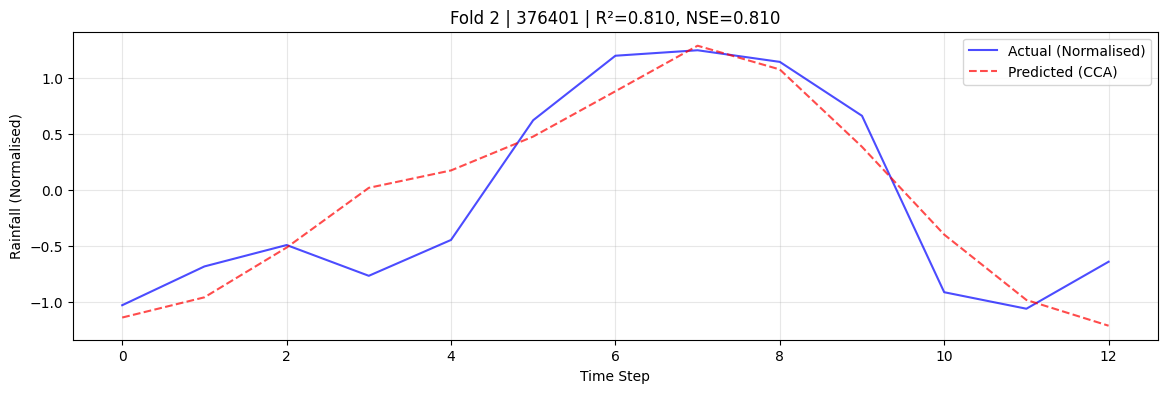

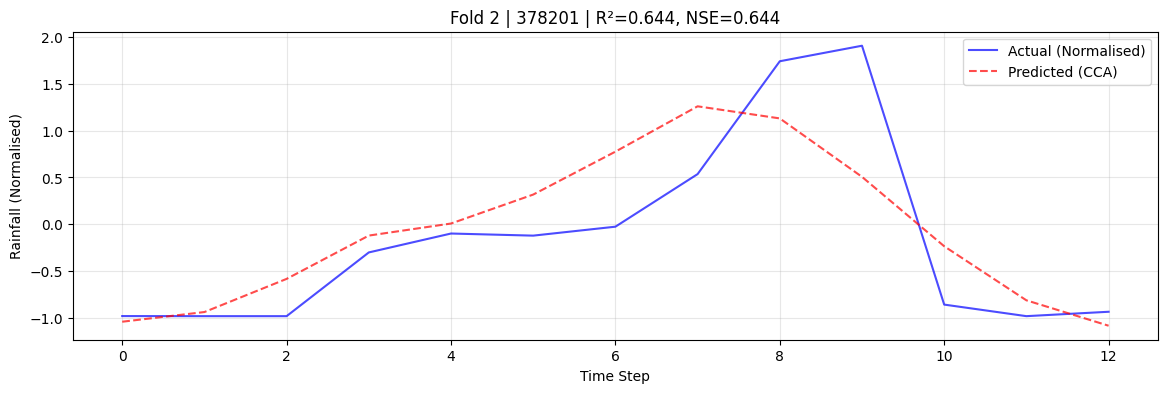

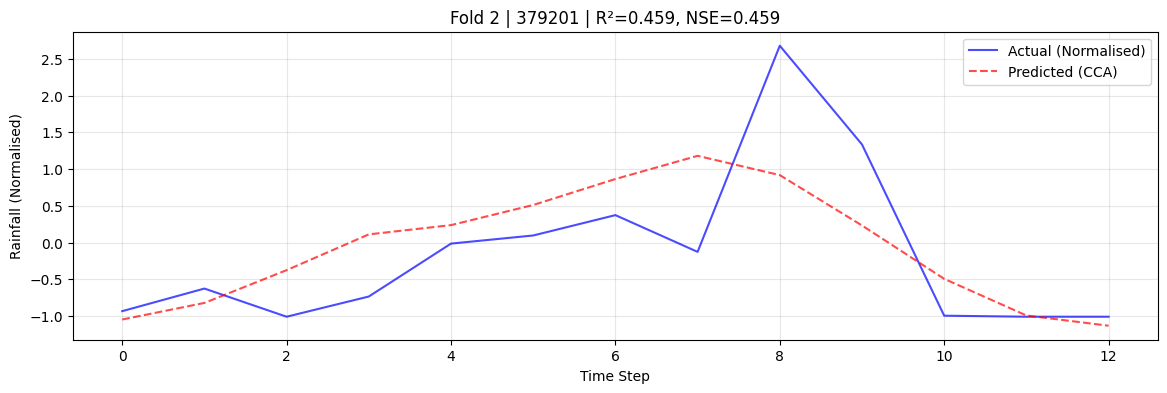

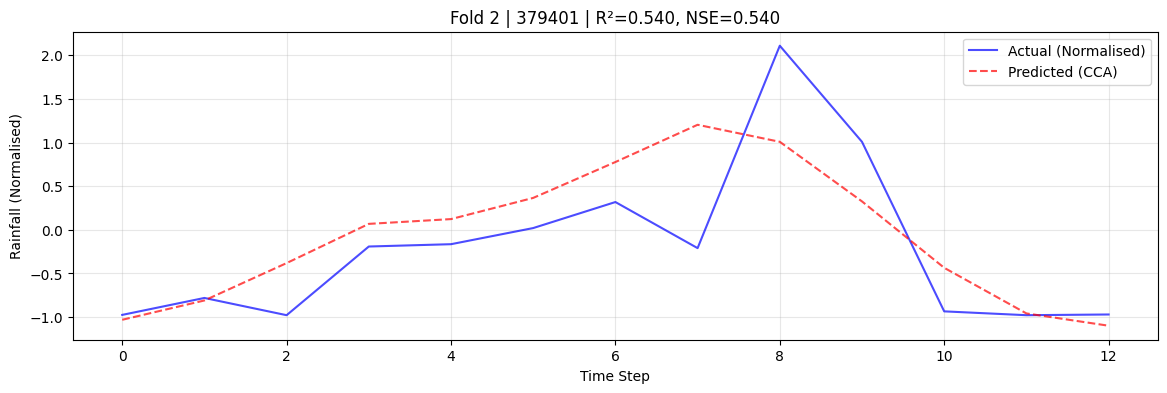

--- Finished Fold 2 ---


In [46]:
print("\n8. Training CCA + Ridge models ...")
print("=" * 60)

fold_results = []

for fold_idx in range(k_fold_num):
    sp = splits[fold_idx]

    X_tr, Y_tr  = build_windows(X_norm_df, Y_norm_df, sp['train'][0], sp['train'][1])
    X_val, Y_val = build_windows(X_norm_df, Y_norm_df, sp['val'][0],   sp['val'][1])
    X_te, Y_te  = build_windows(X_norm_df, Y_norm_df, sp['test'][0],  sp['test'][1])

    print(f"\n--- Fold {fold_idx+1} ---")

    # ... (ส่วน CCA และ Ridge คงเดิมไว้) ...
    n_comp = min(n_components, X_tr.shape[1], Y_tr.shape[1], X_tr.shape[0] - 1)
    cca = CCA(n_components=n_comp, max_iter=1000)
    cca.fit(X_tr, Y_tr)
    Xc_tr, Yc_tr = cca.transform(X_tr, Y_tr)
    Xc_te, Yc_te = cca.transform(X_te, Y_te)

    ridge = Ridge(alpha=ridge_alpha)
    ridge.fit(Xc_tr, Y_tr)
    Y_pred_te = ridge.predict(Xc_te)

    # --- ส่วนที่แก้ไข: วาดกราฟทุกสถานีใน Fold นี้ ---
    print(f"Generating plots for Fold {fold_idx+1}...")

    for i in range(len(cluster_station)):
        # สร้าง Figure ใหม่สำหรับทุกสถานี เพื่อให้แยกรูปกันชัดเจน
        plt.figure(figsize=(14, 4))

        # ดึงค่าจริงและค่าทำนาย
        actual = Y_te[:, i]
        predicted = Y_pred_te[:, i]

        # คำนวณ Metric รายสถานี
        r2_st = r2_score(actual, predicted)
        nse_st = nse_score(actual, predicted)

        # วาดกราฟ
        plt.plot(actual, label='Actual (Normalised)', color='blue', alpha=0.7)
        plt.plot(predicted, label='Predicted (CCA)', color='red', linestyle='--', alpha=0.7)

        # ใช้ชื่อสถานีจาก station_names หรือ cluster_station
        st_name = station_names[i] if i < len(station_names) else f"Station {i+1}"

        plt.title(f"Fold {fold_idx+1} | {st_name} | R²={r2_st:.3f}, NSE={nse_st:.3f}")
        plt.xlabel("Time Step")
        plt.ylabel("Rainfall (Normalised)")
        plt.legend(loc='upper right')
        plt.grid(alpha=0.3)

        # แสดงผลทันทีใน Colab
        plt.show()

    print(f"--- Finished Fold {fold_idx+1} ---")

##  14. SUMMARY TABLE

In [47]:
print("\n" + "=" * 60)
print("9. Results Summary")
print("=" * 60)

results_df = pd.DataFrame(fold_results)
print(results_df.to_string(index=False))
results_df.to_csv(os.path.join(OUTPUT_DIR, 'cca_results_summary.csv'), index=False)


9. Results Summary
Empty DataFrame
Columns: []
Index: []


##  15. CCA LOADINGS PLOT

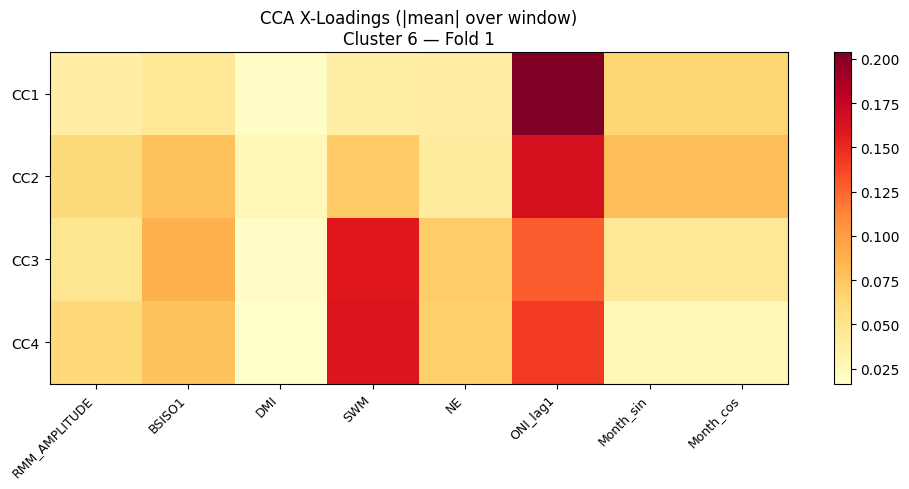

In [48]:
# Re-train on Fold 1 train set for loadings
sp0 = splits[0]
X_tr0, Y_tr0 = build_windows(X_norm_df, Y_norm_df, sp0['train'][0], sp0['train'][1])

n_comp0 = min(n_components, X_tr0.shape[1], Y_tr0.shape[1], X_tr0.shape[0] - 1)
cca0    = CCA(n_components=n_comp0, max_iter=1000)
cca0.fit(X_tr0, Y_tr0)

# X loadings: coefficients for each original climate-window feature per component
# Summarise by mean absolute loading per climate variable
n_feat = len(climate_name_list)

x_loadings = cca0.x_weights_[:, :n_comp0]  # [n_feat * window, n_comp]
# Reshape to [n_feat, window, n_comp] and take mean absolute across time
x_load_reshaped = x_loadings.reshape(window_size, n_feat, n_comp0)
x_load_mean     = np.abs(x_load_reshaped).mean(axis=0)  # [n_feat, n_comp]

fig2, ax2 = plt.subplots(figsize=(10, 5))
im = ax2.imshow(x_load_mean.T, aspect='auto', cmap='YlOrRd')
ax2.set_xticks(range(n_feat))
ax2.set_xticklabels(climate_name_list, rotation=45, ha='right', fontsize=9)
ax2.set_yticks(range(n_comp0))
ax2.set_yticklabels([f'CC{i+1}' for i in range(n_comp0)])
ax2.set_title(f"CCA X-Loadings (|mean| over window)\nCluster {cluster} — Fold 1")
plt.colorbar(im, ax=ax2)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'cca_x_loadings.png'), dpi=130)
plt.show()

##  16. CANONICAL CORRELATION BAR CHART

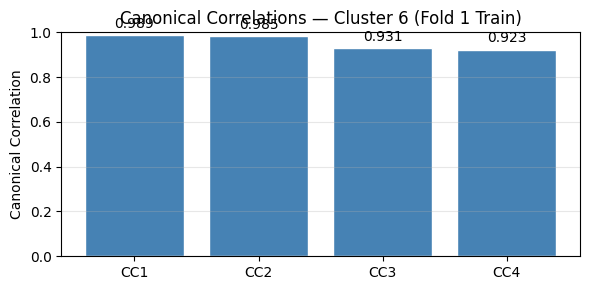

In [49]:
X_tr0_c, Y_tr0_c = cca0.transform(X_tr0, Y_tr0)
canon_corrs0 = [np.corrcoef(X_tr0_c[:, k], Y_tr0_c[:, k])[0, 1] for k in range(n_comp0)]

fig3, ax3 = plt.subplots(figsize=(6, 3))
bars = ax3.bar([f'CC{i+1}' for i in range(n_comp0)], canon_corrs0,
               color='steelblue', edgecolor='white')
ax3.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax3.set_ylim(0, 1)
ax3.set_ylabel('Canonical Correlation')
ax3.set_title(f'Canonical Correlations — Cluster {cluster} (Fold 1 Train)')
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'cca_canonical_correlations.png'), dpi=130)
plt.show()

# print("\nDone! Output files:")
# for fn in ['cca_actual_vs_predicted.png', 'cca_x_loadings.png',
#            'cca_canonical_correlations.png', 'cca_results_summary.csv']:
#     print(f"  {os.path.join(OUTPUT_DIR, fn)}")